In [1]:
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import hydrogenbonds
import matplotlib.pyplot as plt
import nglview as nv

In [2]:
%matplotlib notebook

In [3]:
# Loads just a .gro single-frame file and checks if there are positions and velocities
grofile = "dropdown.gro"
xtcfile = "dropdown_whole.xtc"

uframe = mda.Universe(grofile)
print(uframe.trajectory.ts.has_positions)
print(uframe.trajectory.ts.has_velocities)

True
True


In [4]:
# Loads the data
u = mda.Universe(grofile, xtcfile)
print(np.shape(u.atoms.positions))
print(u.trajectory.ts.has_positions)
print(u.trajectory.ts.has_velocities)

(11588, 3)
True
False


In [5]:
# Turn this on if we want to look at the trajectory
TOTview = nv.show_mdanalysis(u)
TOTview.clear()
TOTview.add_contact(hydrogen_bond=True) # This slows things down a lot
TOTview.add_representation('licorice',selection='SOL',opacity=0.3)
TOTview.add_representation('ball+stick',selection='RNA')
TOTview.add_representation('ball+stick',selection='NA',color='green',radius=.3)
TOTview.camera='orthographic'
TOTview.center()
TOTview.add_unitcell()
TOTview.control.rotate([0,1,0,0])
TOTview

NGLWidget(max_frame=1)

In [6]:
# Specify coordinates we want
Pterm = u.select_atoms('name P')[0]
O1Pterm = u.select_atoms('name O1P')[0]
O2Pterm = u.select_atoms('name O2P')[0]
NAterm = u.select_atoms('name NA')[0]

In [7]:
# Extract some coordinates (and time)
P_position = []
O1P_position = []
O2P_position = []
NA_position = []
pullforce = []
pullx = []
time = []
for ts in u.trajectory:     # iterate through all frames
    P_position.append(Pterm.position) # end-to-end vector fr
    O1P_position.append(O1Pterm.position)
    O2P_position.append(O2Pterm.position)
    NA_position.append(NAterm.position)
#     if pulling:
#         pullforce.append(u.trajectory.ts.aux['pull'])
#         pullx.append(u.trajectory.ts.aux['pullx'])
    time.append(u.trajectory.time)
print(np.shape(P_position))
print(np.shape(time))
time = np.array(time)/1e3
Ntimes = len(time)

(2, 3)
(2,)


In [8]:
# Making numpy arrays, in nanometers
P_position_x = np.array(P_position)[:,0]/10
P_position_y = np.array(P_position)[:,1]/10
P_position_z = np.array(P_position)[:,2]/10
O1P_position_x = np.array(O1P_position)[:,0]/10
O1P_position_y = np.array(O1P_position)[:,1]/10
O1P_position_z = np.array(O1P_position)[:,2]/10
O2P_position_x = np.array(O2P_position)[:,0]/10
O2P_position_y = np.array(O2P_position)[:,1]/10
O2P_position_z = np.array(O2P_position)[:,2]/10
NA_position_x = np.array(NA_position)[:,0]/10
NA_position_y = np.array(NA_position)[:,1]/10
NA_position_z = np.array(NA_position)[:,2]/10

<IPython.core.display.Javascript object>


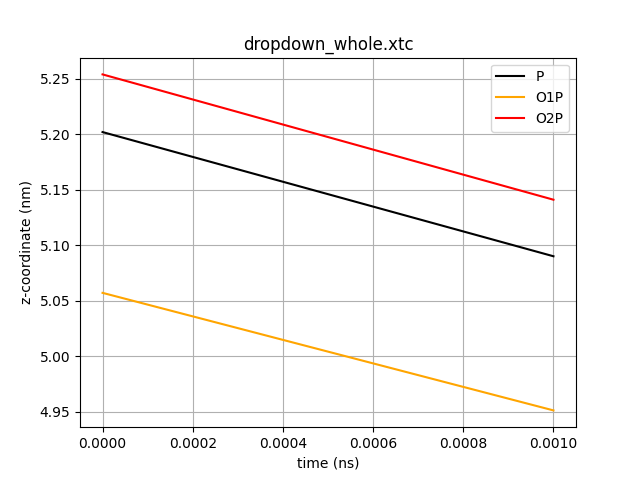

<IPython.core.display.Javascript object>


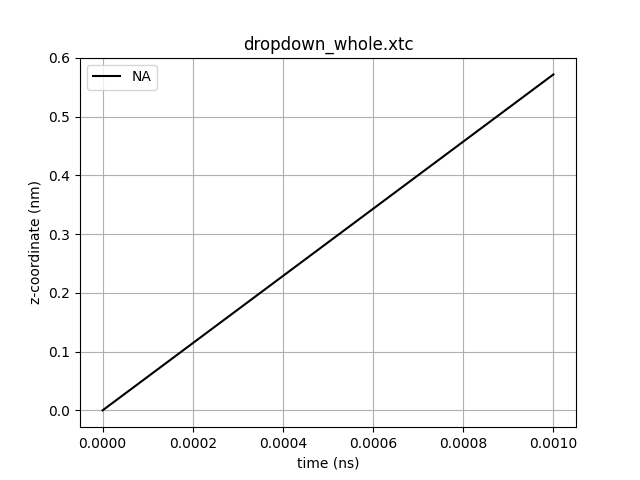

Text(0.5, 1.0, 'dropdown_whole.xtc')

In [9]:
# z-coordinate graphics
plt.figure()
plt.plot(time,P_position_z,'k',label='P')
plt.plot(time,O1P_position_z,'orange',label='O1P')
plt.plot(time,O2P_position_z,'red',label='O2P')
plt.grid(True)
plt.xlabel('time (ns)')
plt.ylabel('z-coordinate (nm)')
plt.legend()
plt.title(xtcfile)

plt.figure()
plt.plot(time,NA_position_z,'k',label='NA')
plt.grid(True)
plt.xlabel('time (ns)')
plt.ylabel('z-coordinate (nm)')
plt.legend()
plt.title(xtcfile)

<IPython.core.display.Javascript object>


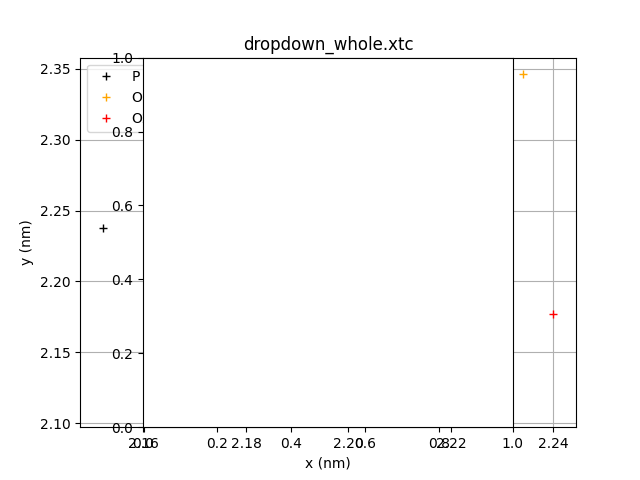

In [10]:
# xy-coordinate graphics
plt.figure()
plt.plot(P_position_x,P_position_y,'k+',label='P')
plt.plot(O1P_position_x,O1P_position_y,'+',color='orange',label='O1P')
plt.plot(O2P_position_x,O2P_position_y,'+',color='red',label='O2P')
plt.grid(True)
plt.xlabel('x (nm)')
plt.ylabel('y (nm)')
plt.legend()
plt.title(xtcfile)
plt.axes().set_aspect('equal')

In [11]:
# Getting the means of the last few hundred points
backfromend = 150
if backfromend > Ntimes:
    backfromend = 0; 
    print ('resetting to entire trajectory')
else:
    print ('using last', backfromend, 'times')
O2P_position_x_mean = np.mean(O2P_position_x[-backfromend:])
O2P_position_y_mean = np.mean(O2P_position_y[-backfromend:])
O2P_position_z_mean = np.mean(O2P_position_z[-backfromend:])
O1P_position_x_mean = np.mean(O1P_position_x[-backfromend:])
O1P_position_y_mean = np.mean(O1P_position_y[-backfromend:])
O1P_position_z_mean = np.mean(O1P_position_z[-backfromend:])

resetting to entire trajectory


In [12]:
# This sets up creation of a 2-d histogram of solvent water, probility(x,y), integrated over z

# Break out the oxygen atoms of the solvent
OWterm_frame = uframe.select_atoms('name OW')
print (np.shape(OWterm_frame.positions))

# Extract coordinates
OWx_frame = OWterm_frame.positions[:,0]/10; print(np.shape(OWx_frame)) # In nm
OWy_frame = OWterm_frame.positions[:,1]/10; print(np.shape(OWy_frame))
OWz_frame = OWterm_frame.positions[:,2]/10; print(np.shape(OWz_frame))

(2880, 3)
(2880,)
(2880,)
(2880,)


y-range = -0.02800000086426735 4.695000171661377
x-range = -0.027000000700354576 4.505000114440918


<IPython.core.display.Javascript object>


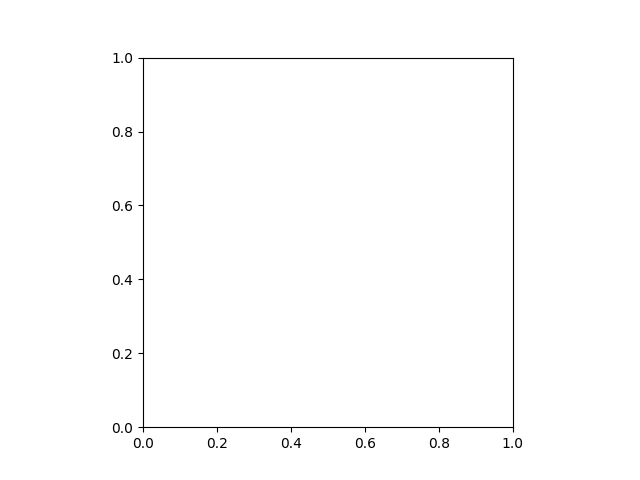

ValueError: 'low' is not a valid value for origin; supported values are 'upper', 'lower'

In [13]:
# Make the x-y histogram
Hyx, yedges, xedges = np.histogram2d(OWy_frame, OWx_frame, bins=[100,100])
print('y-range =',yedges[0], yedges[-1])
print('x-range =',xedges[0], xedges[-1])

# Graphics for the x-y histogram with RNA grid superimposed
plt.figure()

# Plot the histogram of where the water molecules are
plt.imshow(Hyx, cmap='Blues', interpolation='bilinear', origin='low', \
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])

# Make equal aspect ratio and record these axes for later    
plt.axes().set_aspect('equal')
axislims = plt.axis()

# Plot the positions of the RNA atom of interest
plt.plot(O2P_position_x,O2P_position_y,'+',color='pink')
plt.plot(O2P_position_x[0],O2P_position_y[0],'ro')
plt.plot(O2P_position_x_mean,O2P_position_y_mean,'r+')

# # Unfortunately, the arrow tends to get buried under the other symbols, so this is not useful
# plt.arrow(\
#                   O2P_position_x[0],O2P_position_y[0],
#                   O2P_position_x_mean-O2P_position_x[0], O2P_position_y_mean-O2P_position_y[0],
# )

# Re-set the axis and tidy up
# plt.xlim([2,3])
# plt.ylim([2,3])
plt.title(xtcfile)
plt.grid(True)
plt.xlabel('x (nm)')
plt.ylabel('y (nm)')

In [15]:
# RNA = uframeRNA.select_atoms('segid RNA')
# TOT.write()
